# Modul 5: GPU Computing Dasar – CUDA
## Langkah 1: Setup dan Verifikasi Lingkungan


In [ ]:
import subprocess, os, re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Verifikasi NVCC
r = subprocess.run(['nvcc','--version'], capture_output=True, text=True)
print('=== NVCC Version ==='); print(r.stdout.strip())

# Info GPU
r2 = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print('\n=== GPU Info ==='); print(r2.stdout)


=== NVCC Version ===
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

=== GPU Info ===
Thu Jun  4 10:52:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |         

In [ ]:
# Buat direktori kerja
os.makedirs('cuda_files', exist_ok=True)
print('Direktori cuda_files siap.')

# Cek compute capability GPU
r3 = subprocess.run(
    'nvidia-smi --query-gpu=name,compute_cap,memory.total --format=csv,noheader',
    shell=True, capture_output=True, text=True)
print('GPU Details:', r3.stdout.strip())


Direktori cuda_files siap.
GPU Details: Tesla T4, 7.5, 15360 MiB


## Langkah 2: CPU Serial – Baseline

In [ ]:
%%writefile cuda_files/vector_add_cpu.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>

void vector_add_cpu(float* A, float* B, float* C, int N) {
    for (int i = 0; i < N; i++) C[i] = A[i] + B[i];
}

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 10000000;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i = 0; i < N; i++) {
        A[i] = (float)rand()/RAND_MAX;
        B[i] = (float)rand()/RAND_MAX;
    }
    auto t0 = std::chrono::high_resolution_clock::now();
    vector_add_cpu(A.data(), B.data(), C.data(), N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok = true;
    for (int i=0;i<10;i++) if (fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw = (3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,ms,bw,(int)ok);
    return 0;
}


Overwriting cuda_files/vector_add_cpu.cpp


In [ ]:
!g++ -O2 -std=c++11 cuda_files/vector_add_cpu.cpp -o cuda_files/vec_cpu
!./cuda_files/vec_cpu 10000000   # uji dengan 10 juta elemen


N=10000000 TIME_MS=14.6250 BW=8.2051 CORRECT=1


## Langkah 3: CPU dengan OpenMP (Parallel Baseline)

In [ ]:
%%writefile cuda_files/vector_add_openmp.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc>1)?atoi(argv[1]):10000000;
    int T = (argc>2)?atoi(argv[2]):4;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i=0;i<N;i++){A[i]=(float)rand()/RAND_MAX;B[i]=(float)rand()/RAND_MAX;}
    omp_set_num_threads(T);
    auto t0 = std::chrono::high_resolution_clock::now();
    #pragma omp parallel for
    for (int i=0;i<N;i++) C[i]=A[i]+B[i];
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok=true;
    for(int i=0;i<10;i++) if(fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw=(3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d THREADS=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,T,ms,bw,(int)ok);
    return 0;
}


Overwriting cuda_files/vector_add_openmp.cpp


In [ ]:
!g++ -O2 -std=c++11 -fopenmp cuda_files/vector_add_openmp.cpp -o cuda_files/vec_omp
!./cuda_files/vec_omp 10000000 4   # 10M elemen, 4 thread


N=10000000 THREADS=4 TIME_MS=13.1653 BW=9.1148 CORRECT=1


## Langkah 4: CUDA Basic – GPU Kernel

In [ ]:
%%writefile cuda_files/vector_add_cuda.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) do { \
    cudaError_t e = (call); \
    if (e != cudaSuccess) { \
        fprintf(stderr, "CUDA error: %s\n", cudaGetErrorString(e)); \
        exit(1); \
    } \
} while(0)

// ─── CUDA Kernel ─────────────────────────────────
__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;  // threads per block
    size_t sz = N * sizeof(float);

    // ─── Alokasi Host ────────────────────────────
    float *h_A=new float[N], *h_B=new float[N], *h_C=new float[N];
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}

    // ─── Alokasi Device ──────────────────────────
    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));

    // ─── CUDA Events untuk timing ────────────────
    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;

    // HtoD transfer
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));

    // Kernel launch
    int blocks = (N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));

    // DtoH transfer
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));

    float total = t_htod + t_kernel + t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}

    printf("N=%d TPB=%d BLOCKS=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,blocks,t_htod,t_kernel,t_dtoh,total,(int)ok);

    delete[]h_A;delete[]h_B;delete[]h_C;
    CHECK(cudaFree(d_A));CHECK(cudaFree(d_B));CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0));CHECK(cudaEventDestroy(ev1));
    return 0;
}


Overwriting cuda_files/vector_add_cuda.cu


In [ ]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_cuda.cu -o cuda_files/vec_cuda
!./cuda_files/vec_cuda 10000000 256   # 10M elemen, 256 thread per block


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 BLOCKS=39063 HTOD=17.3686 KERNEL=0.6583 DTOH=26.6261 TOTAL=44.6531 CORRECT=1


## Langkah 5: CUDA Pinned Memory – Transfer Lebih Cepat


In [ ]:
%%writefile cuda_files/vector_add_pinned.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) \
do { \
    cudaError_t e = (call); \
    if (e != cudaSuccess) { \
        fprintf(stderr, "CUDA error %s:%d: %s\n", \
                __FILE__, __LINE__, cudaGetErrorString(e)); \
        exit(1); \
    } \
} while(0)

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;
    size_t sz = N * sizeof(float);

    // ─── Pinned memory (page-locked) ─────────────
    float *h_A, *h_B, *h_C;
    CHECK(cudaHostAlloc(&h_A, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_B, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_C, sz, cudaHostAllocDefault));
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}

    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));

    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;

    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));

    int blocks=(N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));

    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));

    float total=t_htod+t_kernel+t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}
    printf("N=%d TPB=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,t_htod,t_kernel,t_dtoh,total,(int)ok);

    CHECK(cudaFreeHost(h_A)); CHECK(cudaFreeHost(h_B)); CHECK(cudaFreeHost(h_C));
    CHECK(cudaFree(d_A)); CHECK(cudaFree(d_B)); CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0)); CHECK(cudaEventDestroy(ev1));
    return 0;
}


Overwriting cuda_files/vector_add_pinned.cu


In [ ]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_pinned.cu -o cuda_files/vec_pinned
!./cuda_files/vec_pinned 10000000 256


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 HTOD=6.5258 KERNEL=0.6632 DTOH=3.1072 TOTAL=10.2962 CORRECT=1


## Langkah 6: Eksperimen Otomatis – Variasi Ukuran Data

In [ ]:
def parse_cpu(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

def parse_cuda(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

sizes = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
results = []

for N in sizes:
    row = {'N': N}
    # CPU Serial
    r = subprocess.run(f'./cuda_files/vec_cpu {N}',   shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['cpu_ms']  = float(d.get('TIME_MS',0))
    # OpenMP (4 thread)
    r = subprocess.run(f'./cuda_files/vec_omp {N} 4', shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['omp_ms']  = float(d.get('TIME_MS',0))
    # CUDA Basic
    r = subprocess.run(f'./cuda_files/vec_cuda {N} 256',shell=True,capture_output=True,text=True)
    d = parse_cuda(r.stdout)
    row['cuda_htod']   = float(d.get('HTOD',0))
    row['cuda_kernel'] = float(d.get('KERNEL',0))
    row['cuda_dtoh']   = float(d.get('DTOH',0))
    row['cuda_total']  = float(d.get('TOTAL',0))
    # CUDA Pinned
    r = subprocess.run(f'./cuda_files/vec_pinned {N} 256',shell=True,capture_output=True,text=True)
    d = parse_cuda(r.stdout); row['pinned_total'] = float(d.get('TOTAL',0))
    results.append(row)
    print(f'N={N:>12,}: cpu={row["cpu_ms"]:8.2f}ms  omp={row["omp_ms"]:7.2f}ms  cuda={row["cuda_total"]:7.2f}ms  pinned={row["pinned_total"]:7.2f}ms')

df = pd.DataFrame(results)
print('\n=== Eksperimen selesai ===')


N=       1,000: cpu=    0.00ms  omp=   0.19ms  cuda=   0.24ms  pinned=   0.19ms
N=      10,000: cpu=    0.01ms  omp=   0.20ms  cuda=   0.25ms  pinned=   0.21ms
N=     100,000: cpu=    0.12ms  omp=   0.22ms  cuda=   0.73ms  pinned=   0.30ms
N=   1,000,000: cpu=    0.85ms  omp=   0.72ms  cuda=   5.08ms  pinned=   1.22ms
N=  10,000,000: cpu=   10.29ms  omp=   9.33ms  cuda=  44.83ms  pinned=  10.27ms
N= 100,000,000: cpu=  104.72ms  omp=  89.36ms  cuda= 505.33ms  pinned=  99.95ms

=== Eksperimen selesai ===


In [ ]:
# Hitung Speedup dan Bandwidth
df['speedup_omp']    = df['cpu_ms'] / df['omp_ms']
df['speedup_cuda']   = df['cpu_ms'] / df['cuda_total']
df['speedup_pinned'] = df['cpu_ms'] / df['pinned_total']
df['pcie_bw_cuda']   = (2*df['N']*4/1e9) / (df['cuda_htod']+df['cuda_dtoh'])*1000  # GB/s
df['pcie_bw_pinned'] = (2*df['N']*4/1e9) / df['pinned_total']*1000

# Cetak tabel ringkasan
print('=== Tabel Waktu Eksekusi (ms) ===')
print(df[['N','cpu_ms','omp_ms','cuda_total','pinned_total']].to_string(index=False))
print('\n=== Tabel Speedup ===')
print(df[['N','speedup_omp','speedup_cuda','speedup_pinned']].to_string(index=False))


=== Tabel Waktu Eksekusi (ms) ===
        N   cpu_ms  omp_ms  cuda_total  pinned_total
     1000   0.0007  0.1929      0.2434        0.1948
    10000   0.0068  0.2040      0.2479        0.2051
   100000   0.1216  0.2199      0.7261        0.2991
  1000000   0.8454  0.7154      5.0812        1.2215
 10000000  10.2932  9.3261     44.8251       10.2719
100000000 104.7151 89.3625    505.3297       99.9451

=== Tabel Speedup ===
        N  speedup_omp  speedup_cuda  speedup_pinned
     1000     0.003629      0.002876        0.003593
    10000     0.033333      0.027430        0.033155
   100000     0.552979      0.167470        0.406553
  1000000     1.181717      0.166378        0.692100
 10000000     1.103698      0.229630        1.002074
100000000     1.171801      0.207221        1.047726


## Langkah 7: Visualisasi Hasil

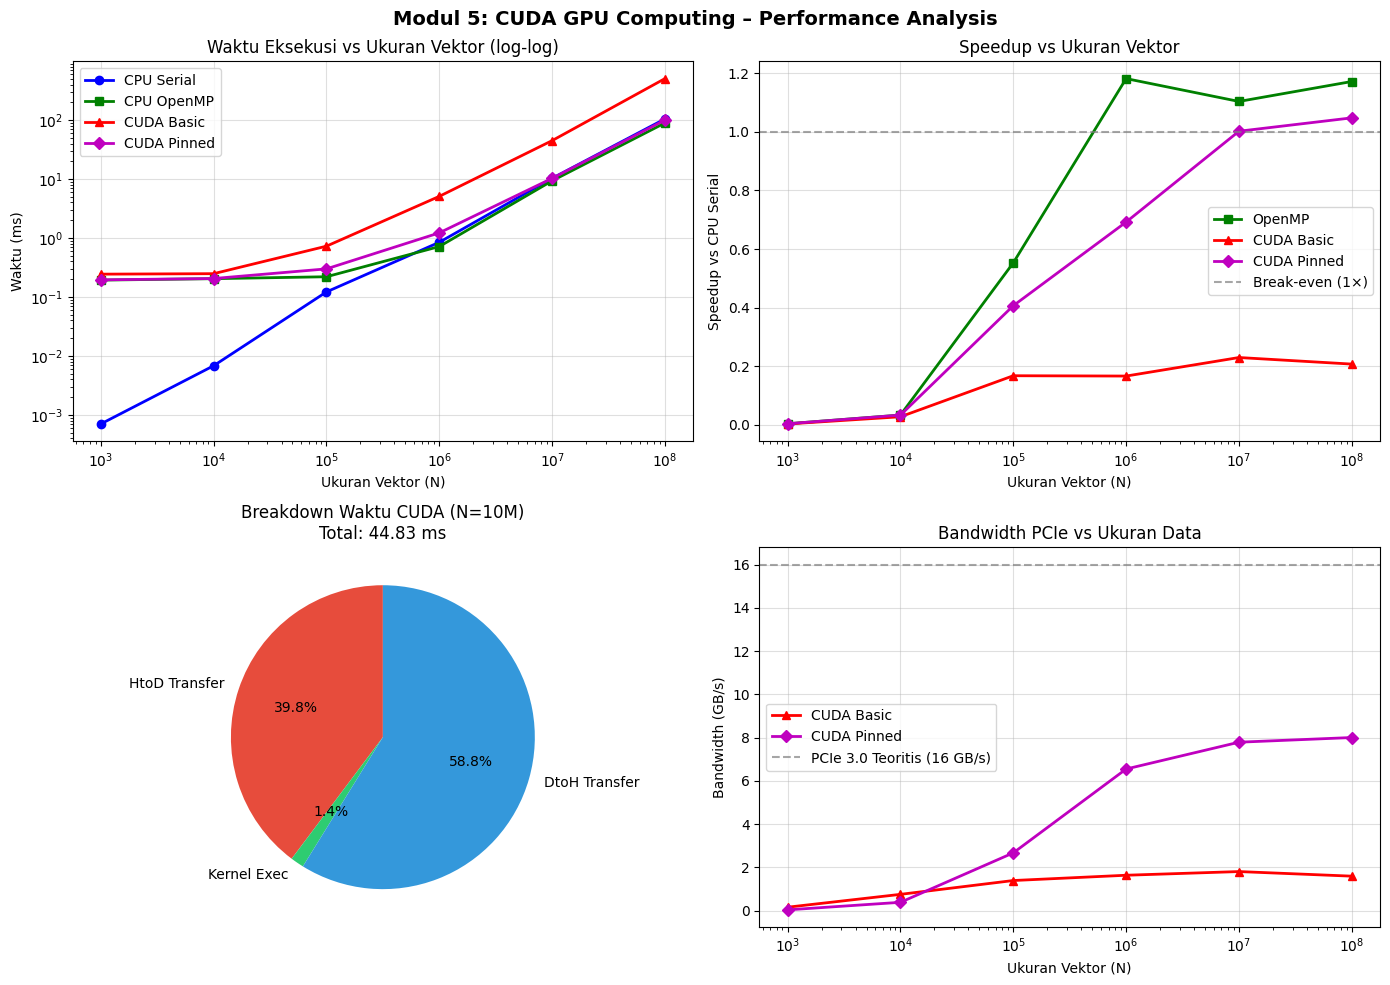

Grafik disimpan ke cuda_files/performance_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sizes_k = [f'{n//1000}K' if n<1e6 else f'{n//1000000}M' for n in df['N']]

# Grafik 1: Waktu Eksekusi (log scale)
ax = axes[0,0]
ax.loglog(df['N'], df['cpu_ms'],    'b-o', label='CPU Serial',  linewidth=2)
ax.loglog(df['N'], df['omp_ms'],    'g-s', label='CPU OpenMP',  linewidth=2)
ax.loglog(df['N'], df['cuda_total'],'r-^', label='CUDA Basic',  linewidth=2)
ax.loglog(df['N'], df['pinned_total'],'m-D',label='CUDA Pinned',linewidth=2)
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Waktu (ms)')
ax.set_title('Waktu Eksekusi vs Ukuran Vektor (log-log)'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 2: Speedup vs CPU Serial
ax = axes[0,1]
ax.semilogx(df['N'], df['speedup_omp'],   'g-s', label='OpenMP',      linewidth=2)
ax.semilogx(df['N'], df['speedup_cuda'],  'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['speedup_pinned'],'m-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Break-even (1×)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Speedup vs CPU Serial')
ax.set_title('Speedup vs Ukuran Vektor'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 3: CUDA Breakdown (10M elemen)
ax = axes[1,0]

row10m = df[df['N']==10_000_000].iloc[0]

labels_b = ['HtoD Transfer', 'Kernel Exec', 'DtoH Transfer']

vals_b = np.array([
    row10m['cuda_htod'],
    row10m['cuda_kernel'],
    row10m['cuda_dtoh']
], dtype=float)

# Bersihkan NaN
vals_b = np.nan_to_num(vals_b, nan=0.0)

colors_b = ['#E74C3C','#2ECC71','#3498DB']

if vals_b.sum() > 0:
    wedges, texts, autotexts = ax.pie(
        vals_b,
        labels=labels_b,
        colors=colors_b,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize':10}
    )

    ax.set_title(
        f'Breakdown Waktu CUDA (N=10M)\n'
        f'Total: {row10m["cuda_total"]:.2f} ms'
    )
else:
    ax.text(
        0.5, 0.5,
        'Data CUDA\nTidak Tersedia',
        ha='center',
        va='center',
        fontsize=12
    )
    ax.set_title('Breakdown Waktu CUDA (N=10M)')
    ax.axis('off')

# Grafik 4: Bandwidth PCIe
ax = axes[1,1]
ax.semilogx(df['N'], df['pcie_bw_cuda'],   'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['pcie_bw_pinned'], 'm-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=16, color='gray', linestyle='--', alpha=0.7, label='PCIe 3.0 Teoritis (16 GB/s)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Bandwidth (GB/s)')
ax.set_title('Bandwidth PCIe vs Ukuran Data'); ax.legend(); ax.grid(True,alpha=0.4)

plt.suptitle('Modul 5: CUDA GPU Computing – Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cuda_files/performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke cuda_files/performance_analysis.png')


## Langkah 8: Eksperimen Konfigurasi Thread per Block

TPB=   32: kernel=1.0108ms  total=46.4277ms
TPB=   64: kernel=0.6347ms  total=45.8704ms
TPB=  128: kernel=0.6283ms  total=44.8877ms
TPB=  256: kernel=0.6060ms  total=45.2176ms
TPB=  512: kernel=0.6689ms  total=50.9491ms
TPB= 1024: kernel=0.6618ms  total=50.0306ms

=== Tabel Thread per Block ===
 ThreadsPerBlock  Blocks  Kernel_ms  Total_ms
              32  312500     1.0108   46.4277
              64  156250     0.6347   45.8704
             128   78125     0.6283   44.8877
             256   39063     0.6060   45.2176
             512   19532     0.6689   50.9491
            1024    9766     0.6618   50.0306


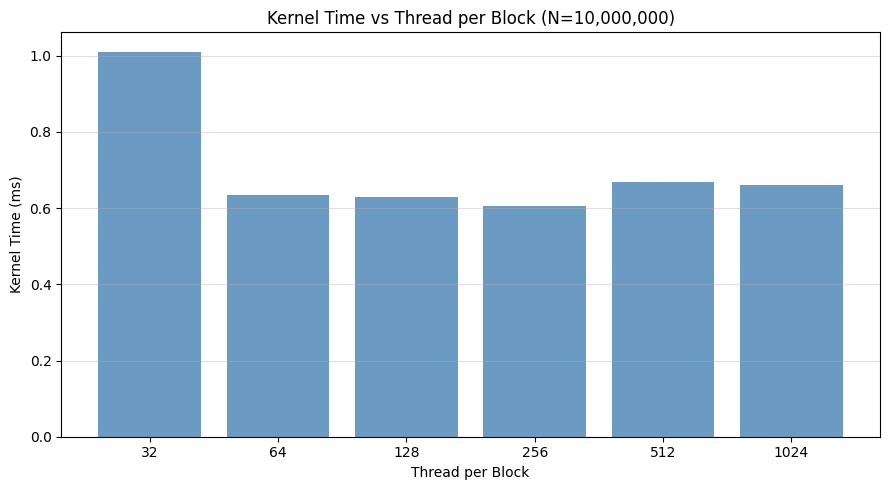

In [ ]:
tpb_configs = [32, 64, 128, 256, 512, 1024]
N_test = 10_000_000
tpb_results = []

for tpb in tpb_configs:
    r = subprocess.run(f'./cuda_files/vec_cuda {N_test} {tpb}',
                       shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout)
    tpb_results.append({
        'ThreadsPerBlock': tpb,
        'Blocks'         : int(d.get('BLOCKS', 0)),
        'Kernel_ms'      : float(d.get('KERNEL',0)),
        'Total_ms'       : float(d.get('TOTAL',0))
    })
    print(f'TPB={tpb:5d}: kernel={float(d.get("KERNEL",0)):.4f}ms  total={float(d.get("TOTAL",0)):.4f}ms')

df_tpb = pd.DataFrame(tpb_results)
print('\n=== Tabel Thread per Block ===')
print(df_tpb.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(range(len(tpb_configs)), df_tpb['Kernel_ms'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(tpb_configs)))
ax.set_xticklabels([str(t) for t in tpb_configs])
ax.set_xlabel('Thread per Block'); ax.set_ylabel('Kernel Time (ms)')
ax.set_title(f'Kernel Time vs Thread per Block (N={N_test:,})')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.savefig('cuda_files/tpb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
